In [1]:
# =====================================================
# CodeAlpha - Task 4: Disease Prediction from Medical Data
# =====================================================

# ---------------------------------------------------------------------
# STEP 1: Import Libraries
# ---------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

In [2]:

# ---------------------------------------------------------------------
# STEP 2: Load Dataset (directly from URL - no upload needed)
# ---------------------------------------------------------------------
url = "https://raw.githubusercontent.com/manishanker/stats_ml_jun2020/master/datasets_737503_1278636_heart.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nTarget class balance:\n", df["target"].value_counts())


Shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target class balance:
 target
1    165
0    138
Name: count, dtype: int64


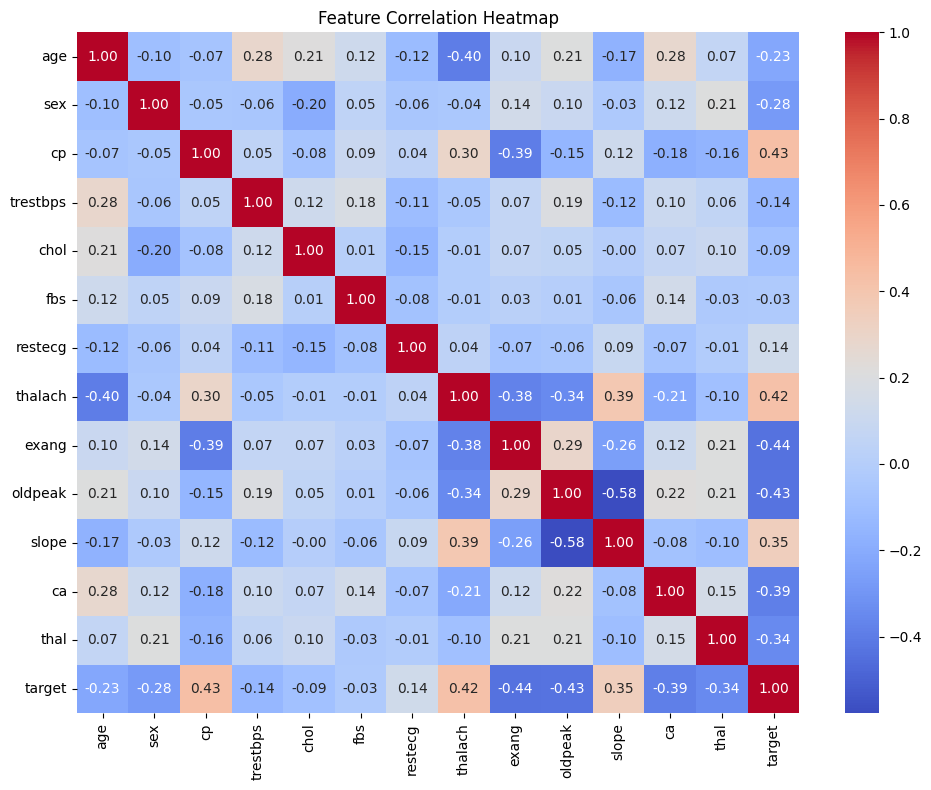

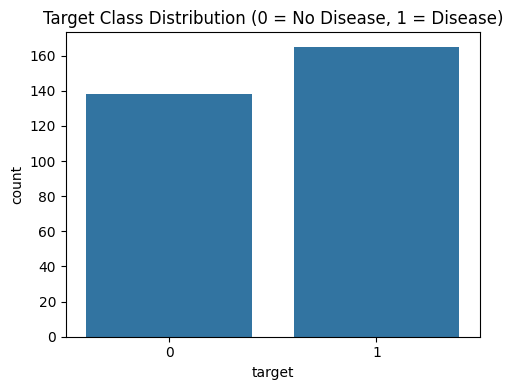

In [3]:

# ---------------------------------------------------------------------
# STEP 3: Exploratory Data Analysis (EDA)
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=df)
plt.title("Target Class Distribution (0 = No Disease, 1 = Disease)")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150)
plt.show()


In [4]:

# ---------------------------------------------------------------------
# STEP 4: Train/Test Split + Feature Scaling
# ---------------------------------------------------------------------
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:

# ---------------------------------------------------------------------
# STEP 5: Train Multiple Models
# ---------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF kernel)": SVC(probability=True, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "ROC-AUC": auc
    })

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))



===== Logistic Regression =====
              precision    recall  f1-score   support

  No Disease       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


===== Random Forest =====
              precision    recall  f1-score   support

  No Disease       0.95      0.64      0.77        28
     Disease       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61


===== SVM (RBF kernel) =====
              precision    recall  f1-score   support

  No Disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81     

In [6]:

# ---------------------------------------------------------------------
# STEP 6: Compare Models
# ---------------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\n===== Model Comparison =====")
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)



===== Model Comparison =====
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest  0.819672   0.761905 0.969697  0.853333 0.912338
   SVM (RBF kernel)  0.819672   0.775000 0.939394  0.849315 0.883117
Logistic Regression  0.803279   0.769231 0.909091  0.833333 0.869048


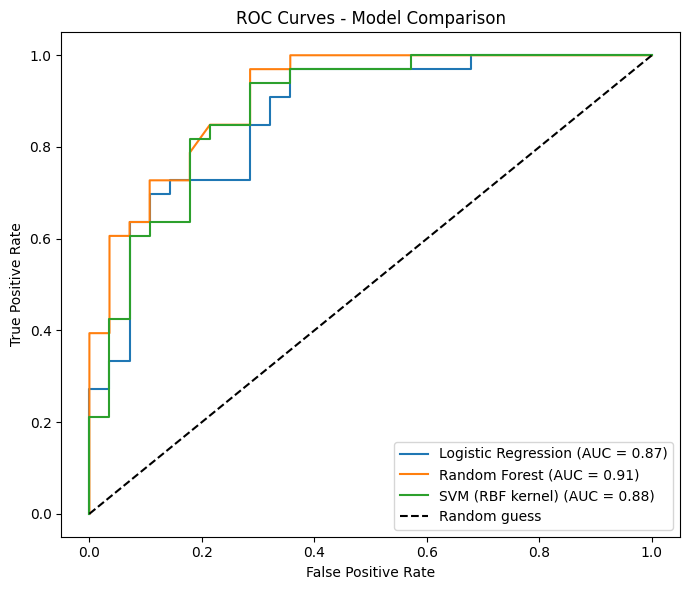

In [7]:

# ---------------------------------------------------------------------
# STEP 7: ROC Curves for All Models
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()


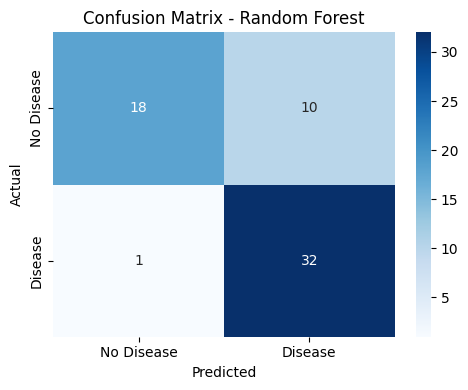


Best model: Random Forest


In [8]:

# ---------------------------------------------------------------------
# STEP 8: Confusion Matrix for Best Model
# ---------------------------------------------------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=150)
plt.show()

print(f"\nBest model: {best_model_name}")



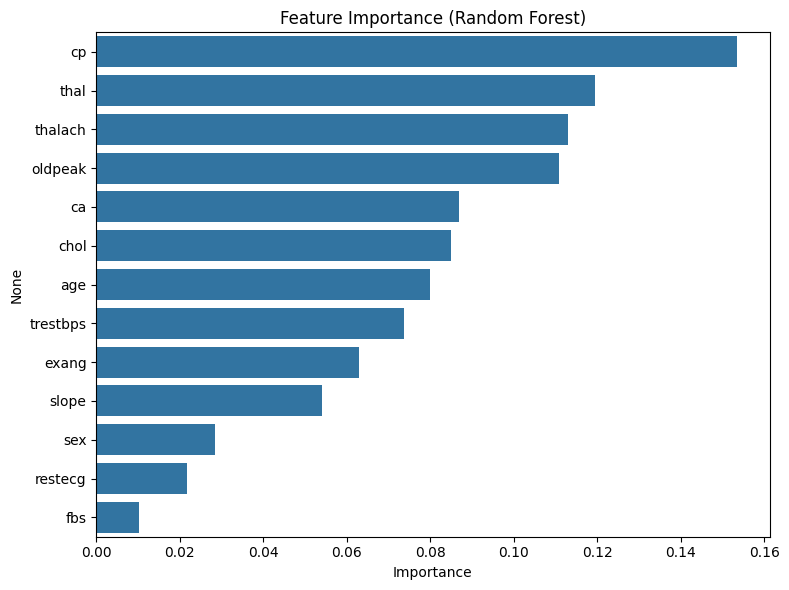


✅ Done! All plots and model_comparison.csv are saved.


In [9]:

# ---------------------------------------------------------------------
# STEP 9: Feature Importance (Random Forest)
# ---------------------------------------------------------------------
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\n✅ Done! All plots and model_comparison.csv are saved.")